# SAM Multi-Cat Extension with Non-Max Suppression

This notebook extends the baseline cat classifier from solo-image classification to images that contain both cats at once. The goal is exploratory: rather than classifying the full image as Tig or Buster, this notebook uses the Segment Anything Model (SAM) to generate candidate object regions, extracts crops from those regions, and classifies each crop as Tig or Buster.

This extension follows the spatial-output framework from object detection and segmentation. SAM proposes candidate masks, non-max suppression removes duplicate or heavily overlapping regions, and a pretrained ResNet18 feature extractor with logistic regression assigns labels to selected crop regions.

Because this pipeline is exploratory, the outputs should be interpreted qualitatively. The goal is to test whether segmentation plus crop classification can identify both cats in the same image, not to claim a fully benchmarked multi-object detector.

## 1. Setup and Imports

This section loads the required packages, sets up the compute device, and imports the Segment Anything Model tools used for candidate mask generation.

In [1]:
from pathlib import Path
import os
import random
import urllib.request

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
from torchvision import transforms

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

classifier_device = torch.device("cpu")

## 2. Load Segment Anything Model

This section loads the SAM ViT-B checkpoint. If the checkpoint file is not already present locally, the notebook downloads it automatically. The notebook attempts to use CUDA when available, but falls back to CPU if GPU memory is unavailable or unstable.

In [2]:
import os

sam_checkpoint = "sam_vit_b_01ec64.pth"

if not os.path.exists(sam_checkpoint):
    print("Downloading SAM checkpoint...")
    urllib.request.urlretrieve(
        "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth",
        sam_checkpoint
    )
    print("Download complete.")

# Lecture 14 uses ViT-B.
sam = sam_model_registry["vit_b"](checkpoint=sam_checkpoint)

# Adaptive device selection.
# Try CUDA only if it is available and stable; otherwise fall back to CPU.
MIN_FREE_GPU_GB = 3.0
sam_device = torch.device("cpu")

if torch.cuda.is_available():
    try:
        free_bytes, total_bytes = torch.cuda.mem_get_info()
        free_gb = free_bytes / (1024 ** 3)
        total_gb = total_bytes / (1024 ** 3)

        print(f"CUDA available: {torch.cuda.get_device_name(0)}")
        print(f"GPU memory free/total: {free_gb:.2f} GB / {total_gb:.2f} GB")

        if free_gb >= MIN_FREE_GPU_GB:
            sam_device = torch.device("cuda")
        else:
            print(f"Free GPU memory is below {MIN_FREE_GPU_GB} GB. Using CPU instead.")

    except Exception as e:
        print("CUDA was detected but could not be used safely.")
        print("Falling back to CPU.")
        print("CUDA error:", e)
        sam_device = torch.device("cpu")
else:
    print("CUDA not available. Using CPU.")

try:
    sam = sam.to(sam_device)
except Exception as e:
    print("Could not move SAM to selected device.")
    print("Falling back to CPU.")
    print("Device error:", e)
    sam_device = torch.device("cpu")
    sam = sam.to(sam_device)

# Laptop-friendly SAM settings.
# 16 is much faster than 32. Use 12 if your laptop is still suffering.
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=16,
    pred_iou_thresh=0.88,
    stability_score_thresh=0.95,
    crop_n_layers=0,
    min_mask_region_area=100,
)

print("SAM device:", sam_device)

CUDA available: NVIDIA GeForce RTX 5050 Laptop GPU
GPU memory free/total: 6.81 GB / 7.96 GB
SAM device: cuda


## 3. Define Paths and Utility Functions

This section defines the project folders, output directory, image extensions, random seed, and helper function for loading image paths.

In [3]:
DATA_DIR = Path("data/raw")
BOTH_DIR = DATA_DIR / "both"
OUTPUT_DIR = Path("outputs/multicat")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

random.seed(SEED)
np.random.seed(SEED)

def get_image_paths(class_dir: Path):
    paths = []
    for p in class_dir.rglob("*"):
        if p.suffix.lower() in IMAGE_EXTS:
            paths.append(p)
    return sorted(paths)

## 4. Rebuild Crop Classifier

The baseline notebook uses CLIP embeddings for whole-image classification. This extension uses a ResNet18 feature extractor for cropped candidate regions because the SAM pipeline produces smaller object crops rather than full images. A logistic regression classifier is trained on solo Tig and Buster images, then applied to crops extracted from both-cat images.

In [4]:
tig_paths = get_image_paths(DATA_DIR / "tig")
buster_paths = get_image_paths(DATA_DIR / "buster")

all_paths = tig_paths + buster_paths
labels = np.array([0] * len(tig_paths) + [1] * len(buster_paths))
label_names = {0: "tig", 1: "buster"}

weights = ResNet18_Weights.DEFAULT
resnet = resnet18(weights=weights)
feature_extractor = nn.Sequential(*list(resnet.children())[:-1]).to(classifier_device)
feature_extractor.eval()

for param in feature_extractor.parameters():
    param.requires_grad = False

img_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

def encode_images(paths, batch_size=16):
    features = []
    valid_paths = []

    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        batch_tensors = []

        for p in batch_paths:
            try:
                img = Image.open(p).convert("RGB")
                batch_tensors.append(img_transform(img))
                valid_paths.append(p)
            except Exception as e:
                print(f"Skipping {p}: {e}")

        if not batch_tensors:
            continue

        batch = torch.stack(batch_tensors).to(classifier_device)

        with torch.no_grad():
            feats = feature_extractor(batch).flatten(1)

        features.append(feats.cpu().numpy())

    return np.vstack(features), valid_paths

X, valid_paths = encode_images(all_paths)
path_to_label = {str(p): y for p, y in zip(all_paths, labels)}
y = np.array([path_to_label[str(p)] for p in valid_paths])

clf = LogisticRegression(max_iter=5000, random_state=SEED)
clf.fit(X, y)

print("Classifier rebuilt.")
print("Feature matrix shape:", X.shape)
print("Tig images:", len(tig_paths))
print("Buster images:", len(buster_paths))

Classifier rebuilt.
Feature matrix shape: (60, 512)
Tig images: 30
Buster images: 30


## 5. Load Both-Cat Images

This section loads images from `data/raw/both`, which contain both Tig and Buster in the same scene. Natural sorting keeps filenames such as `both2.jpg` before `both10.jpg`.

In [5]:
import re

def natural_key(p):
    return [int(x) if x.isdigit() else x.lower()
            for x in re.split(r'(\d+)', p.stem)]

both_paths = sorted(get_image_paths(BOTH_DIR), key=natural_key)

for i, p in enumerate(both_paths):
    print(i, p.name)

0 both1.jpg
1 both2.jpg
2 both3.jpg
3 both4.jpg
4 both5.jpg
5 both6.jpg
6 both7.jpg
7 both8.jpg
8 both9.jpg
9 both10.jpg
10 both11.jpg
11 both12.jpg


## 6. Convert SAM Masks into Candidate Crops

SAM returns segmentation masks rather than directly returning classifier-ready image crops. These helper functions convert masks into bounding boxes and extract candidate crop regions while filtering out very small regions or regions that cover most of the image.

In [6]:
def mask_to_box(mask):
    ys, xs = np.where(mask)
    if len(xs) == 0 or len(ys) == 0:
        return None
    return xs.min(), ys.min(), xs.max(), ys.max()

def extract_candidate_crops(image_pil, sam_masks, min_area=2000, max_frac=0.8):
    img_np = np.array(image_pil)
    H, W = img_np.shape[:2]
    crops = []

    for m in sam_masks:
        binary = m["segmentation"]
        area = m["area"]
        if area < min_area:
            continue

        box = mask_to_box(binary)
        if box is None:
            continue

        x1, y1, x2, y2 = box
        box_area = (x2 - x1 + 1) * (y2 - y1 + 1)
        if box_area > max_frac * H * W:
            continue

        crop = image_pil.crop((x1, y1, x2 + 1, y2 + 1))
        crops.append({
            "crop": crop,
            "box": (x1, y1, x2, y2),
            "mask_area": area
        })

    return crops


## 7. Non-Max Suppression

SAM often generates many overlapping masks for the same object or nearby object parts. Non-max suppression reduces this redundancy by sorting candidate masks by quality score and removing lower-scoring masks whose bounding boxes overlap too much with a mask already selected.

In [7]:
def box_iou(box_a, box_b):
    """
    Compute IoU between two boxes in (x1, y1, x2, y2) format.
    """
    ax1, ay1, ax2, ay2 = [float(v) for v in box_a]
    bx1, by1, bx2, by2 = [float(v) for v in box_b]

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0.0, inter_x2 - inter_x1 + 1)
    inter_h = max(0.0, inter_y2 - inter_y1 + 1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, ax2 - ax1 + 1) * max(0.0, ay2 - ay1 + 1)
    area_b = max(0.0, bx2 - bx1 + 1) * max(0.0, by2 - by1 + 1)

    union = area_a + area_b - inter_area
    if union == 0:
        return 0.0

    return inter_area / union


def sam_mask_to_box(mask_dict):
    """
    Convert a SAM mask dictionary to (x1, y1, x2, y2).
    SAM stores bbox as [x, y, width, height], but this function also
    falls back to the binary mask if bbox is unavailable.
    """
    if "bbox" in mask_dict:
        x, y, w, h = mask_dict["bbox"]
        return (x, y, x + w, y + h)

    return mask_to_box(mask_dict["segmentation"])


def sam_mask_score(mask_dict):
    """
    Score a SAM mask using SAM's internal quality estimates.
    Higher score = keep earlier during non-max suppression.
    """
    predicted_iou = mask_dict.get("predicted_iou", 0.0)
    stability_score = mask_dict.get("stability_score", 0.0)
    area = mask_dict.get("area", 0.0)

    return predicted_iou + 0.5 * stability_score + 1e-8 * area


def non_max_suppression_masks(
    masks,
    image_shape,
    iou_threshold=0.35,
    min_area=2000,
    max_area_frac=0.80
):
    """
    Apply non-max suppression to SAM masks.

    This keeps high-quality masks and removes lower-scoring masks whose
    bounding boxes overlap too much with a mask that has already been kept.
    """
    height, width = image_shape[:2]
    image_area = height * width

    filtered_masks = []

    for m in masks:
        area = m.get("area", 0)

        if area < min_area:
            continue

        if area > max_area_frac * image_area:
            continue

        box = sam_mask_to_box(m)
        if box is None:
            continue

        m = dict(m)
        m["nms_box"] = box
        m["nms_score"] = sam_mask_score(m)
        filtered_masks.append(m)

    masks_sorted = sorted(
        filtered_masks,
        key=lambda m: m["nms_score"],
        reverse=True
    )

    kept_masks = []

    for candidate in masks_sorted:
        candidate_box = candidate["nms_box"]

        should_keep = True

        for kept in kept_masks:
            kept_box = kept["nms_box"]

            if box_iou(candidate_box, kept_box) > iou_threshold:
                should_keep = False
                break

        if should_keep:
            kept_masks.append(candidate)

    return kept_masks


def non_max_suppression_results(
    results,
    iou_threshold=0.30,
    max_detections=2
):
    """
    Apply NMS to classified crop results.

    This is a second cleanup step after classification. It keeps the most
    confident crop predictions and removes overlapping lower-confidence boxes.
    """
    results_sorted = sorted(
        results,
        key=lambda r: r["confidence"],
        reverse=True
    )

    kept_results = []

    for candidate in results_sorted:
        candidate_box = candidate["box"]

        should_keep = True

        for kept in kept_results:
            kept_box = kept["box"]

            if box_iou(candidate_box, kept_box) > iou_threshold:
                should_keep = False
                break

        if should_keep:
            kept_results.append(candidate)

        if max_detections is not None and len(kept_results) >= max_detections:
            break

    return kept_results

## 8. Classify Candidate Crops

Each selected crop is passed through the ResNet18 feature extractor and then classified with logistic regression. The classifier returns the predicted cat label and confidence for each candidate crop.

In [8]:
def classify_candidate_crops(crops, clf):
    if len(crops) == 0:
        return []

    batch = torch.stack([
        img_transform(c["crop"].convert("RGB")) for c in crops
    ]).to(classifier_device)

    with torch.no_grad():
        X_crops = feature_extractor(batch).flatten(1).cpu().numpy()

    pred_labels = clf.predict(X_crops)
    pred_probs = clf.predict_proba(X_crops)

    results = []
    for crop_info, pred, probs in zip(crops, pred_labels, pred_probs):
        results.append({
            "box": crop_info["box"],
            "crop": crop_info["crop"],
            "pred": label_names[int(pred)],
            "prob_tig": float(probs[0]),
            "prob_buster": float(probs[1]),
            "confidence": float(np.max(probs))
        })

    results = sorted(results, key=lambda x: x["confidence"], reverse=True)
    return results

## 9. Detection Selection Helpers

These helper functions choose cleaner detections by preferring confident boxes while penalizing very large or edge-clipped boxes. This is useful for difficult multi-cat examples where the highest-confidence crop is not always the most interpretable crop.

In [9]:
def box_area_fraction(box, image_shape):
    """
    Compute the fraction of the full image covered by a detection box.
    """
    img_h, img_w = image_shape[:2]
    x1, y1, x2, y2 = [int(v) for v in box]

    box_area = max(0, x2 - x1) * max(0, y2 - y1)
    image_area = img_h * img_w

    return box_area / image_area


def box_edge_penalty(box, image_shape, edge_margin_frac=0.02):
    """
    Penalize boxes that touch the image boundary.

    Edge-clipped boxes are often partial objects or background regions.
    """
    img_h, img_w = image_shape[:2]
    x1, y1, x2, y2 = [int(v) for v in box]

    x_margin = edge_margin_frac * img_w
    y_margin = edge_margin_frac * img_h

    penalty = 0

    if x1 <= x_margin:
        penalty += 1
    if y1 <= y_margin:
        penalty += 1
    if x2 >= img_w - x_margin:
        penalty += 1
    if y2 >= img_h - y_margin:
        penalty += 1

    return penalty


def candidate_quality_score(result, image_shape):
    """
    Prefer confident detections, but penalize very large or edge-clipped boxes.
    """
    confidence = result["confidence"]
    area_frac = box_area_fraction(result["box"], image_shape)
    edge_penalty = box_edge_penalty(result["box"], image_shape)

    return confidence - 0.60 * area_frac - 0.08 * edge_penalty


def best_result_for_class(results, class_name, image_shape, min_confidence=0.60):
    """
    Select the best detection for one class using the quality score.
    """
    class_results = [
        r for r in results
        if r["pred"] == class_name and r["confidence"] >= min_confidence
    ]

    if len(class_results) == 0:
        return None

    return max(
        class_results,
        key=lambda r: candidate_quality_score(r, image_shape)
    )


def select_best_multicat_results(filtered_results, image_shape, min_confidence=0.60):
    """
    Try to keep one Tig detection and one Buster detection.
    If one class is missing, fall back to the two best detections overall.
    """
    best_results = []

    best_tig = best_result_for_class(
        filtered_results,
        class_name="tig",
        image_shape=image_shape,
        min_confidence=min_confidence
    )

    best_buster = best_result_for_class(
        filtered_results,
        class_name="buster",
        image_shape=image_shape,
        min_confidence=min_confidence
    )

    if best_tig is not None:
        best_results.append(best_tig)

    if best_buster is not None:
        best_results.append(best_buster)

    if len(best_results) < 2:
        filtered_results_sorted = sorted(
            filtered_results,
            key=lambda r: candidate_quality_score(r, image_shape),
            reverse=True
        )
        best_results = filtered_results_sorted[:2]

    return best_results

## 10. Full Multi-Cat Pipeline

This function combines the full workflow for one both-cat image: SAM mask generation, mask-level NMS, crop extraction, crop classification, classification-level NMS, plotting, and saving the labeled output image.

In [10]:
def run_multicat_example(
    image_path,
    output_name,
    title=None,
    mask_iou_threshold=0.35,
    result_iou_threshold=0.30,
    min_area=2000,
    max_area_frac=0.80,
    max_detections=2,
    figsize=(8, 8)
):
    """
    Run the full SAM -> mask NMS -> crop extraction -> classification ->
    result NMS pipeline on one both-cat image.
    """
    image_path = Path(image_path)

    image = Image.open(image_path).convert("RGB")
    image_np = np.array(image).astype(np.uint8)

    raw_sam_masks = mask_generator.generate(image_np)

    sam_masks = non_max_suppression_masks(
        raw_sam_masks,
        image_shape=image_np.shape,
        iou_threshold=mask_iou_threshold,
        min_area=min_area,
        max_area_frac=max_area_frac
    )

    crops = extract_candidate_crops(
        image,
        sam_masks,
        min_area=min_area,
        max_frac=max_area_frac
    )

    raw_results = classify_candidate_crops(crops, clf)

    results = non_max_suppression_results(
        raw_results,
        iou_threshold=result_iou_threshold,
        max_detections=max_detections
    )

    print(f"\n=== {image_path.name} ===")
    print("Raw SAM masks:", len(raw_sam_masks))
    print("SAM masks after NMS:", len(sam_masks))
    print("Candidate crops after mask filtering:", len(crops))
    print("Raw classified crop results:", len(raw_results))
    print("Final detections after classification NMS:", len(results))

    print("Final predictions:")
    for r in results:
        print(r["pred"], round(r["confidence"], 3), r["box"])

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image)

    for r in results:
        x1, y1, x2, y2 = r["box"]

        rect = plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2
        )
        ax.add_patch(rect)

        ax.text(
            x1,
            y1 - 5,
            f'{r["pred"]} ({r["confidence"]:.2f})',
            color="yellow",
            fontsize=10,
            bbox=dict(facecolor="black", alpha=0.6, pad=2)
        )

    if title is None:
        title = f"SAM + NMS detections for {image_path.name}"

    ax.set_title(title)
    ax.axis("off")
    plt.tight_layout()

    save_path = OUTPUT_DIR / output_name
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved to:", save_path)

    return {
        "image_path": image_path,
        "raw_sam_masks": raw_sam_masks,
        "sam_masks": sam_masks,
        "crops": crops,
        "raw_results": raw_results,
        "results": results,
        "save_path": save_path
    }

Both-cat images: 12

=== both1.jpg ===
Raw SAM masks: 12
SAM masks after NMS: 11
Candidate crops after mask filtering: 11
Raw classified crop results: 11
Final detections after classification NMS: 2
Final predictions:
buster 1.0 (np.int64(2047), np.int64(185), np.int64(3999), np.int64(1930))
tig 0.996 (np.int64(1225), np.int64(691), np.int64(2101), np.int64(1409))


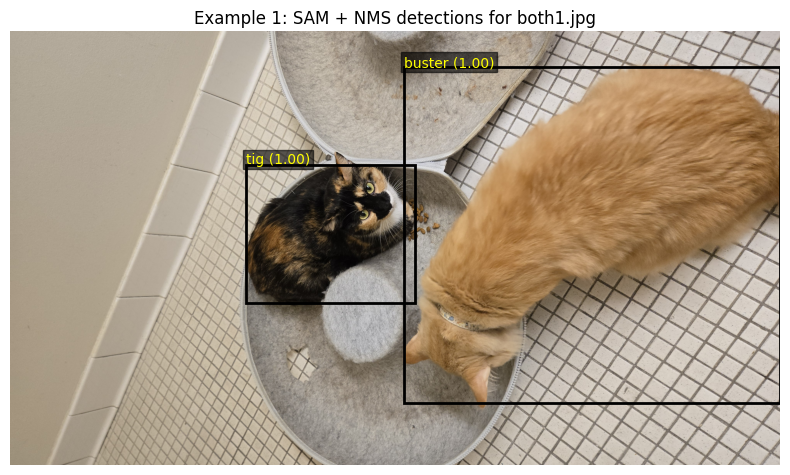

Saved to: outputs\multicat\both1_nms_labeled.png


In [11]:
both_paths = sorted(get_image_paths(BOTH_DIR), key=natural_key)
print("Both-cat images:", len(both_paths))

if len(both_paths) == 0:
    raise ValueError(f"No both-cat images found in {BOTH_DIR.resolve()}")

example1 = run_multicat_example(
    image_path=both_paths[0],
    output_name="both1_nms_labeled.png",
    title="Example 1: SAM + NMS detections for both1.jpg",
    max_detections=2
)

used_both_examples = {Path(example1["image_path"]).resolve()}

## 11. Second Successful Multi-Cat Example

This example runs the same SAM + NMS pipeline on a second both-cat image. I use a fixed example rather than searching randomly across many images so the notebook stays reproducible and avoids repeatedly running SAM, which can be slow and memory-intensive.

Using image: data\raw\both\both10.jpg
Raw SAM masks: 29
SAM masks after NMS: 27
Candidate crops after mask filtering: 27
Raw classified crop results: 27
Filtered classified results after NMS: 27
Best results to plot:
tig 0.996 (np.int64(2653), np.int64(1105), np.int64(3374), np.int64(1579))
buster 0.873 (np.int64(198), np.int64(1062), np.int64(846), np.int64(1377))


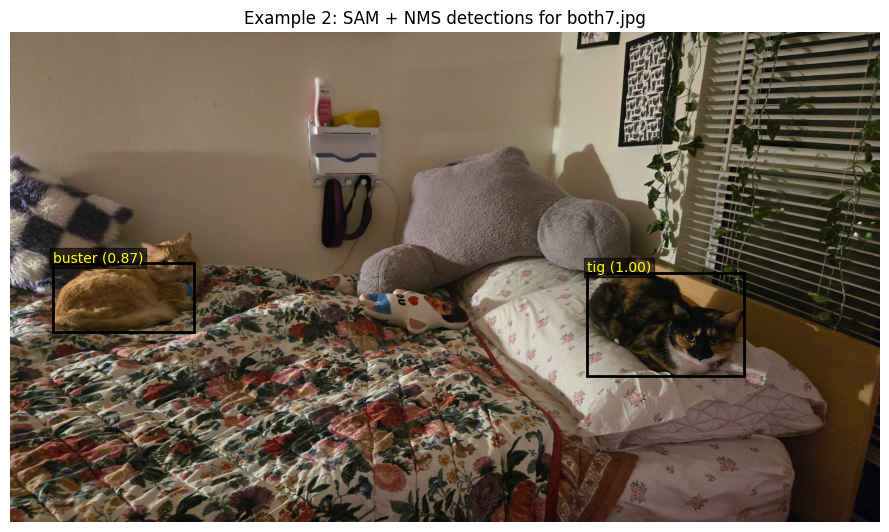

Saved to: outputs\multicat\both7_nms_labeled.png


In [24]:
image_path = BOTH_DIR / "both10.jpg"
print("Using image:", image_path)

image = Image.open(image_path).convert("RGB")
image_np = np.array(image).astype(np.uint8)

# SAM step: generate raw masks.
raw_sam_masks = mask_generator.generate(image_np)

# NMS step: remove duplicate or heavily overlapping SAM masks.
sam_masks = non_max_suppression_masks(
    raw_sam_masks,
    image_shape=image_np.shape,
    iou_threshold=0.35,
    min_area=2000,
    max_area_frac=0.80
)

# Turn filtered masks into crops, then classify each crop.
crops = extract_candidate_crops(
    image,
    sam_masks,
    min_area=2000,
    max_frac=0.80
)

raw_results = classify_candidate_crops(crops, clf)

# Do not limit to the top two immediately.
# First remove overlapping boxes, then select one Tig and one Buster.
filtered_results = non_max_suppression_results(
    raw_results,
    iou_threshold=0.30,
    max_detections=None
)

results = select_best_multicat_results(
    filtered_results,
    image_shape=image_np.shape,
    min_confidence=0.60
)

print("Raw SAM masks:", len(raw_sam_masks))
print("SAM masks after NMS:", len(sam_masks))
print("Candidate crops after mask filtering:", len(crops))
print("Raw classified crop results:", len(raw_results))
print("Filtered classified results after NMS:", len(filtered_results))

print("Best results to plot:")
for r in results:
    print(r["pred"], round(r["confidence"], 3), r["box"])

try:
    used_both_examples.add(Path(image_path).resolve())
except NameError:
    used_both_examples = {Path(image_path).resolve()}

fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(image)

for r in results:
    x1, y1, x2, y2 = r["box"]

    rect = plt.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        linewidth=2
    )
    ax.add_patch(rect)

    label_y = max(10, y1 - 5)

    ax.text(
        x1,
        label_y,
        f'{r["pred"]} ({r["confidence"]:.2f})',
        color="yellow",
        fontsize=10,
        bbox=dict(facecolor="black", alpha=0.6, pad=2)
    )

ax.set_title("Example 2: SAM + NMS detections for both7.jpg")
ax.axis("off")
plt.tight_layout()

save_path = OUTPUT_DIR / "both7_nms_labeled.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

example2 = {
    "image_path": image_path,
    "raw_sam_masks": raw_sam_masks,
    "sam_masks": sam_masks,
    "crops": crops,
    "raw_results": raw_results,
    "results": results,
    "save_path": save_path
}

print("Saved to:", save_path)

## 12. Additional Curated-Random Multi-Cat Example

This section runs the SAM + NMS pipeline on one additional both-cat image chosen reproducibly from a small curated set of usable examples. The image is selected with a fixed random seed, so the notebook remains reproducible while still showing the pipeline on a third multi-cat scene.

To avoid repeatedly running SAM across many high-resolution images, this section chooses one candidate image and runs mask generation only once. The output is interpreted qualitatively because the project does not include hand-labeled bounding boxes or formal object-detection metrics. The goal is to show how the pipeline behaves on another realistic both-cat image, not to claim a fully benchmarked detector.

Using curated-random additional image: data\raw\both\both2.jpg
Raw SAM masks: 15
SAM masks after NMS: 8
Candidate crops after mask filtering: 8
Raw classified crop results: 8
Filtered classified results after NMS: 8
Best results to plot:
tig 0.98 (np.int64(0), np.int64(1610), np.int64(391), np.int64(2251))
buster 0.96 (np.int64(2757), np.int64(0), np.int64(3999), np.int64(690))


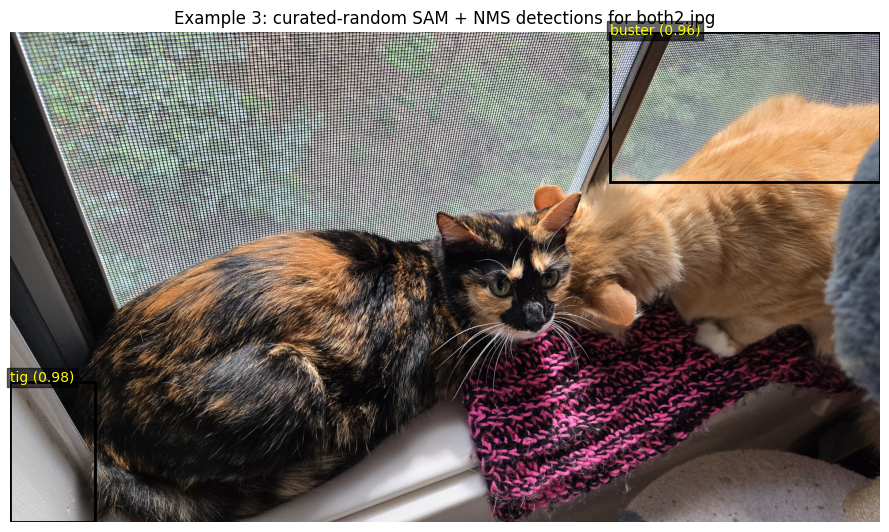

Saved to: outputs\multicat\both2_curated_random_nms_labeled.png


In [25]:
# Additional curated-random multi-cat example.
# This chooses one image from a small curated set of usable both-cat examples,
# then runs SAM only once to avoid repeated memory-heavy mask generation.

curated_extra_examples = [
    BOTH_DIR / "both2.jpg",
    BOTH_DIR / "both6.jpg",
    BOTH_DIR / "both7.jpg",
    BOTH_DIR / "both8.jpg",
    BOTH_DIR / "both9.jpg",
    BOTH_DIR / "both11.jpg",
    BOTH_DIR / "both12.jpg",
]

# Keep only files that actually exist and have not already been used.
try:
    already_used = used_both_examples
except NameError:
    already_used = set()

candidate_both_paths = [
    p for p in curated_extra_examples
    if p.exists() and p.resolve() not in already_used
]

if len(candidate_both_paths) == 0:
    raise ValueError("No unused curated both-cat examples are available.")

rng = random.Random(SEED + 17)
extra_image_path = rng.choice(candidate_both_paths)

print("Using curated-random additional image:", extra_image_path)

image = Image.open(extra_image_path).convert("RGB")
image_np = np.array(image).astype(np.uint8)

# Use a larger minimum candidate area to reduce tiny background artifacts.
min_candidate_area = 80000

# SAM step: generate raw masks.
raw_sam_masks = mask_generator.generate(image_np)

# NMS step: remove duplicate or heavily overlapping SAM masks.
sam_masks = non_max_suppression_masks(
    raw_sam_masks,
    image_shape=image_np.shape,
    iou_threshold=0.35,
    min_area=min_candidate_area,
    max_area_frac=0.80
)

# Turn filtered masks into crops, then classify each crop.
crops = extract_candidate_crops(
    image,
    sam_masks,
    min_area=min_candidate_area,
    max_frac=0.80
)

raw_results = classify_candidate_crops(crops, clf)

# Final NMS cleanup after classification.
filtered_results = non_max_suppression_results(
    raw_results,
    iou_threshold=0.30,
    max_detections=None
)

# Select one Tig result and one Buster result when possible.
results = select_best_multicat_results(
    filtered_results,
    image_shape=image_np.shape,
    min_confidence=0.60
)

print("Raw SAM masks:", len(raw_sam_masks))
print("SAM masks after NMS:", len(sam_masks))
print("Candidate crops after mask filtering:", len(crops))
print("Raw classified crop results:", len(raw_results))
print("Filtered classified results after NMS:", len(filtered_results))

print("Best results to plot:")
for r in results:
    print(r["pred"], round(r["confidence"], 3), r["box"])

try:
    used_both_examples.add(extra_image_path.resolve())
except NameError:
    used_both_examples = {extra_image_path.resolve()}

fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(image)

for r in results:
    x1, y1, x2, y2 = r["box"]

    rect = plt.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        linewidth=2
    )
    ax.add_patch(rect)

    label_y = max(10, y1 - 5)

    ax.text(
        x1,
        label_y,
        f'{r["pred"]} ({r["confidence"]:.2f})',
        color="yellow",
        fontsize=10,
        bbox=dict(facecolor="black", alpha=0.6, pad=2)
    )

ax.set_title(f"Example 3: curated-random SAM + NMS detections for {extra_image_path.name}")
ax.axis("off")
plt.tight_layout()

save_path = OUTPUT_DIR / f"{extra_image_path.stem}_curated_random_nms_labeled.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

example3 = {
    "image_path": extra_image_path,
    "raw_sam_masks": raw_sam_masks,
    "sam_masks": sam_masks,
    "crops": crops,
    "raw_results": raw_results,
    "results": results,
    "save_path": save_path
}

print("Saved to:", save_path)

## 13. Save SAM Extension Summary

This final section saves a short text summary of the SAM multi-cat extension. Unlike the baseline classifier, this extension does not have hand-labeled bounding boxes, so the output is not a formal accuracy report. Instead, the summary records the number of raw SAM masks, masks after non-max suppression, candidate crops, final detections, and predicted labels for the example images.

In [ ]:
# Save a lightweight summary of the SAM multi-cat extension results.

summary_path = OUTPUT_DIR / "sam_multicat_summary.txt"

example_summaries = []

for example_name in ["example1", "example2"]:
    if example_name in globals():
        ex = globals()[example_name]
        example_summaries.append({
            "name": example_name,
            "image": ex["image_path"].name,
            "raw_sam_masks": len(ex["raw_sam_masks"]),
            "sam_masks_after_nms": len(ex["sam_masks"]),
            "candidate_crops": len(ex["crops"]),
            "raw_classified_results": len(ex["raw_results"]),
            "final_detections": len(ex["results"]),
            "predictions": [
                f'{r["pred"]} ({r["confidence"]:.3f})'
                for r in ex["results"]
            ],
            "save_path": ex["save_path"]
        })

with open(summary_path, "w") as f:
    f.write("SAM Multi-Cat Extension Summary\n")
    f.write("===============================\n\n")
    f.write(f"Both-cat images available: {len(both_paths)}\n")
    f.write(f"Solo Tig images used for crop classifier: {len(tig_paths)}\n")
    f.write(f"Solo Buster images used for crop classifier: {len(buster_paths)}\n")
    f.write("Crop feature extractor: ResNet18 pretrained on ImageNet\n")
    f.write("Crop classifier: Logistic regression\n")
    f.write("Mask generator: Segment Anything Model, ViT-B\n")
    f.write("Post-processing: non-max suppression on SAM masks and classified crop boxes\n\n")

    f.write("Interpretation note:\n")
    f.write(
        "This extension is qualitative rather than a formal detection benchmark. "
        "The project does not include hand-labeled bounding boxes, so the outputs "
        "are inspected visually rather than scored with object-detection metrics.\n\n"
    )

    for ex in example_summaries:
        f.write(f"Example: {ex['name']}\n")
        f.write(f"Image: {ex['image']}\n")
        f.write(f"Raw SAM masks: {ex['raw_sam_masks']}\n")
        f.write(f"SAM masks after NMS: {ex['sam_masks_after_nms']}\n")
        f.write(f"Candidate crops: {ex['candidate_crops']}\n")
        f.write(f"Raw classified results: {ex['raw_classified_results']}\n")
        f.write(f"Final detections: {ex['final_detections']}\n")
        f.write("Predictions: " + ", ".join(ex["predictions"]) + "\n")
        f.write(f"Saved output: {ex['save_path']}\n\n")

print("Saved SAM summary to:", summary_path)

Saved SAM summary to: outputs\multicat\sam_multicat_summary.txt
